#### Modules

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import f1_score
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from copy import deepcopy

#### Train and testing splits 

Stratify ensures training, validation and testing datasets have the exact same proportion of crack and uncrack as the original dataset

In [27]:
# Load datasets
df_walls = pd.read_pickle('wall_data.pkl')
df_decks = pd.read_pickle('deck_data.pkl')

# Split the Walls DataFrame (15% of total wall data for validation, hence 0.15 / 0.85 ≈ 0.176 for second split)
walls, walls_te = train_test_split(df_walls, test_size=0.2, random_state=42, stratify=df_walls['Label'])
walls_tr, walls_val = train_test_split(walls, test_size=0.176, random_state=42, stratify=walls['Label'])

# Split the Decks DataFrame
decks, decks_te = train_test_split(df_decks, test_size=0.2, random_state=42, stratify=df_decks['Label'])
decks_tr, decks_val = train_test_split(decks, test_size=0.176, random_state=42, stratify=decks['Label'])

#### CNN Architecture

In [ ]:
class CNNBinary(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 30 * 30, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


class EarlyStopping:
    def __init__(self, patience=5, min_delta=0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = float("inf")
        self.counter = 0
        self.best_state = None

    def __call__(self, val_loss, model):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            self.best_state = deepcopy(model.state_dict())
            return False

        self.counter += 1
        return self.counter >= self.patience

label_map = {'Non-Cracked': 0.0, 'Cracked': 1.0}

In [ ]:
def calculate_pos_weight(dataframe, label_map):
    labels = dataframe['Label'].map(label_map).values
    num_neg = (labels == 0).sum()
    num_pos = (labels == 1).sum()
    if num_pos == 0:
        return torch.tensor(1.0)
    pos_weight = num_neg / num_pos
    return torch.tensor(pos_weight, dtype=torch.float32)


# Calculate pos_weight for both datasets
pos_weight_walls = calculate_pos_weight(walls_tr, label_map)
pos_weight_decks = calculate_pos_weight(decks_tr, label_map)

print(f"Walls - Class Balance (pos_weight): {pos_weight_walls.item():.2f} (ratio of Non-Cracked to Cracked)")
print(f"Decks - Class Balance (pos_weight): {pos_weight_decks.item():.2f} (ratio of Non-Cracked to Cracked)")

# Define loss functions (you can switch between weighted BCE and Focal Loss)
criterion_bce_weighted_walls = nn.BCEWithLogitsLoss(pos_weight=pos_weight_walls.to(device))
criterion_bce_weighted_decks = nn.BCEWithLogitsLoss(pos_weight=pos_weight_decks.to(device))

# Use weighted BCE loss for training
criterion = criterion_bce_weighted_walls  # Will be updated per dataset during training

Walls - Class Balance (pos_weight): 3.78 (ratio of Non-Cracked to Cracked)
Decks - Class Balance (pos_weight): 5.97 (ratio of Non-Cracked to Cracked)


#### Data Generator (Memory Efficient)

Instead of loading all images into memory at once, we use a generator that loads images in batches during training.

In [16]:
# Custom PyTorch dataset (memory efficient)
class CrackDataset(Dataset):
    def __init__(self, dataframe, label_map):
        self.dataframe = dataframe.reset_index(drop=True)
        self.label_map = label_map

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]

        image = row['ImageData'].astype(np.float32) / 255.0
        if image.ndim == 2:
            image = np.stack([image] * 3, axis=-1)

        image = np.transpose(image, (2, 0, 1))
        x = torch.from_numpy(image)
        y = torch.tensor(self.label_map[row['Label']], dtype=torch.float32)

        return x, y

#### Training phase

In [ ]:
# Select device - supports NVIDIA CUDA, Apple Metal (M-chips), or CPU fallback
if torch.cuda.is_available():
    device = torch.device("cuda")
    device_type = "NVIDIA CUDA"
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available() and torch.backends.mps.is_built():
    device = torch.device("mps")
    device_type = "Apple Metal (M-chip)"
else:
    device = torch.device("cpu")
    device_type = "CPU"

print(f"Using device: {device} ({device_type})")

model_walls = CNNBinary().to(device)
model_decks = CNNBinary().to(device)

optimizer_walls = optim.Adam(model_walls.parameters(), lr=1e-3)
optimizer_decks = optim.Adam(model_decks.parameters(), lr=1e-3)


def train_model(model, train_loader, val_loader, optimizer, criterion_loss, device, epochs=300, patience=5):
    """
    Improved training with F1 score monitoring and support for weighted/focal loss
    
    Args:
        criterion_loss: Loss function (e.g., weighted BCE or Focal Loss)
    """
    early_stopper = EarlyStopping(patience=patience)
    history = {
        "train_loss": [], "train_acc": [], "train_f1": [],
        "val_loss": [], "val_acc": [], "val_f1": []
    }

    best_f1_val = 0.0

    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        all_train_preds = []
        all_train_labels = []

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            logits = model(images).squeeze(1)
            loss = criterion_loss(logits, labels)
            loss.backward()
            
            # For MPS backend on Apple Silicon, use synchronize to ensure proper gradient updates
            if device.type == "mps":
                torch.mps.synchronize()
                
            optimizer.step()

            running_loss += loss.item() * labels.size(0)
            preds = (torch.sigmoid(logits) >= 0.5).float()
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            
            all_train_preds.extend(preds.detach().cpu().numpy())
            all_train_labels.extend(labels.detach().cpu().numpy())

        train_loss = running_loss / total
        train_acc = correct / total
        train_f1 = f1_score(all_train_labels, all_train_preds, zero_division=0)

        model.eval()
        val_running_loss, val_correct, val_total = 0.0, 0, 0
        all_val_preds = []
        all_val_labels = []

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device)

                logits = model(images).squeeze(1)
                loss = criterion_loss(logits, labels)

                val_running_loss += loss.item() * labels.size(0)
                preds = (torch.sigmoid(logits) >= 0.5).float()
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)
                
                all_val_preds.extend(preds.cpu().numpy())
                all_val_labels.extend(labels.cpu().numpy())

        val_loss = val_running_loss / val_total
        val_acc = val_correct / val_total
        val_f1 = f1_score(all_val_labels, all_val_preds, zero_division=0)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["train_f1"].append(train_f1)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["val_f1"].append(val_f1)

        print(f"Epoch {epoch+1}/{epochs} - "
              f"train_loss: {train_loss:.4f}, train_f1: {train_f1:.4f} | "
              f"val_loss: {val_loss:.4f}, val_f1: {val_f1:.4f}")

        # Early stopping based on F1 score instead of loss
        if val_f1 > best_f1_val:
            best_f1_val = val_f1
            early_stopper.best_state = deepcopy(model.state_dict())
            early_stopper.counter = 0
        else:
            early_stopper.counter += 1
            if early_stopper.counter >= patience:
                print("Early stopping triggered (F1 score not improving).")
                break

    if early_stopper.best_state is not None:
        model.load_state_dict(early_stopper.best_state)

    return history

Using device: cuda (NVIDIA CUDA)


In [ ]:
# Create data loaders for Walls dataset (memory efficient)
train_ds_walls = CrackDataset(walls_tr, label_map)
val_ds_walls = CrackDataset(walls_val, label_map)
test_ds_walls = CrackDataset(walls_te, label_map)

# pin_memory optimization is specific to NVIDIA CUDA (not applicable to MPS or CPU)
pin_memory = torch.cuda.is_available()
train_loader_walls = DataLoader(train_ds_walls, batch_size=32, shuffle=True, num_workers=0, pin_memory=pin_memory)
val_loader_walls = DataLoader(val_ds_walls, batch_size=32, shuffle=False, num_workers=0, pin_memory=pin_memory)
test_loader_walls = DataLoader(test_ds_walls, batch_size=32, shuffle=False, num_workers=0, pin_memory=pin_memory)

In [ ]:
# Create data loaders for Decks dataset (memory efficient)
train_ds_decks = CrackDataset(decks_tr, label_map)
val_ds_decks = CrackDataset(decks_val, label_map)
test_ds_decks = CrackDataset(decks_te, label_map)

# pin_memory optimization is specific to NVIDIA CUDA (not applicable to MPS or CPU)
pin_memory = torch.cuda.is_available()
train_loader_decks = DataLoader(train_ds_decks, batch_size=32, shuffle=True, num_workers=0, pin_memory=pin_memory)
val_loader_decks = DataLoader(val_ds_decks, batch_size=32, shuffle=False, num_workers=0, pin_memory=pin_memory)
test_loader_decks = DataLoader(test_ds_decks, batch_size=32, shuffle=False, num_workers=0, pin_memory=pin_memory)

In [ ]:
# Train using weighted loss (better handling of class imbalance)
print("Training with Weighted Loss (BCE with pos_weight)...\n")
history_walls = train_model(
    model_walls,
    train_loader_walls,
    val_loader_walls,
    optimizer_walls,
    criterion_bce_weighted_walls,
    device,
    epochs=300,
    patience=5)

history_decks = train_model(
    model_decks,
    train_loader_decks,
    val_loader_decks,
    optimizer_decks,
    criterion_bce_weighted_decks,
    device,
    epochs=300,
    patience=5
)

Epoch 1/300 - train_loss: 0.5393, train_acc: 0.7880, val_loss: 0.5151, val_acc: 0.7910
Epoch 2/300 - train_loss: 0.5170, train_acc: 0.7911, val_loss: 0.5043, val_acc: 0.7922
Epoch 3/300 - train_loss: 0.4954, train_acc: 0.8043, val_loss: 0.4707, val_acc: 0.8072
Epoch 4/300 - train_loss: 0.5038, train_acc: 0.7999, val_loss: 0.4857, val_acc: 0.8021
Epoch 5/300 - train_loss: 0.4619, train_acc: 0.8181, val_loss: 0.4689, val_acc: 0.8163
Epoch 6/300 - train_loss: 0.4311, train_acc: 0.8348, val_loss: 0.4372, val_acc: 0.8266
Epoch 7/300 - train_loss: 0.3952, train_acc: 0.8469, val_loss: 0.4464, val_acc: 0.8274
Epoch 8/300 - train_loss: 0.3483, train_acc: 0.8694, val_loss: 0.4514, val_acc: 0.8242
Epoch 9/300 - train_loss: 0.2977, train_acc: 0.8872, val_loss: 0.5998, val_acc: 0.8131
Epoch 10/300 - train_loss: 0.2569, train_acc: 0.9054, val_loss: 0.5520, val_acc: 0.8159
Epoch 11/300 - train_loss: 0.1961, train_acc: 0.9311, val_loss: 0.5801, val_acc: 0.8052
Early stopping triggered.
Epoch 1/300 - t

#### Evaluation Metrics - Recall, Precision, Confusion Matrix

In [ ]:
def evaluate_model(model, test_loader, device, dataset_name=""):
    # Evaluate model and compute recall, precision, confusion matrix
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)
            
            logits = model(images).squeeze(1)
            preds = (torch.sigmoid(logits) >= 0.5).float()
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    
    cm = confusion_matrix(all_labels, all_preds)
    report = classification_report(all_labels, all_preds, 
                                   target_names=['Non-Cracked', 'Cracked'],
                                   output_dict=True)
    
    print(f"\n{'='*60}")
    print(f"Test Set Evaluation - {dataset_name}")
    print(f"{'='*60}")
    print(f"\nConfusion Matrix:\n{cm}")
    print(f"\nClassification Report:\n{classification_report(all_labels, all_preds, target_names=['Non-Cracked', 'Cracked'])}")
    
    # Extract metrics
    recall_non_cracked = report['Non-Cracked']['recall']
    recall_cracked = report['Cracked']['recall']
    precision_non_cracked = report['Non-Cracked']['precision']
    precision_cracked = report['Cracked']['precision']
    
    print(f"\nPrecision (Non-Cracked): {precision_non_cracked:.4f}")
    print(f"Precision (Cracked): {precision_cracked:.4f}")
    print(f"Recall (Non-Cracked): {recall_non_cracked:.4f}")
    print(f"Recall (Cracked): {recall_cracked:.4f}")
    
    return cm, report, all_preds, all_labels


# Evaluate both models on test sets
cm_walls, report_walls, preds_walls, labels_walls = evaluate_model(model_walls, test_loader_walls, device, "Walls Dataset")
cm_decks, report_decks, preds_decks, labels_decks = evaluate_model(model_decks, test_loader_decks, device, "Decks Dataset")


Test Set Evaluation - Walls Dataset

Confusion Matrix:
[[2790   48]
 [ 525  225]]

Classification Report:
              precision    recall  f1-score   support

 Non-Cracked       0.84      0.98      0.91      2838
     Cracked       0.82      0.30      0.44       750

    accuracy                           0.84      3588
   macro avg       0.83      0.64      0.67      3588
weighted avg       0.84      0.84      0.81      3588


Precision (Non-Cracked): 0.8416
Precision (Cracked): 0.8242
Recall (Non-Cracked): 0.9831
Recall (Cracked): 0.3000

Test Set Evaluation - Decks Dataset

Confusion Matrix:
[[2287   13]
 [ 327   58]]

Classification Report:
              precision    recall  f1-score   support

 Non-Cracked       0.87      0.99      0.93      2300
     Cracked       0.82      0.15      0.25       385

    accuracy                           0.87      2685
   macro avg       0.85      0.57      0.59      2685
weighted avg       0.87      0.87      0.83      2685


Precision (Non-C


Finding Optimal Classification Thresholds

Walls Model - Best Threshold (F1): 0.200 (F1 score: 0.4761)
Decks Model - Best Threshold (F1): 0.120 (F1 score: 0.3573)


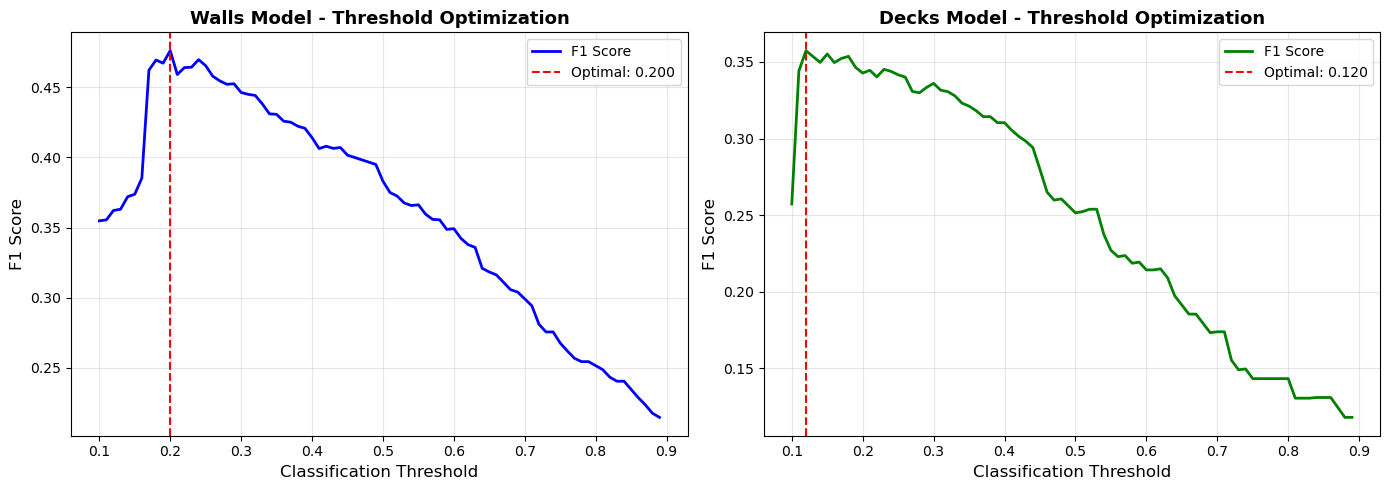

In [ ]:
def optimize_threshold(model, val_loader, device, metric='f1'):
    # Find optimal classification threshold that maximizes F1 score or recall
    model.eval()
    all_logits = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)
            
            logits = model(images).squeeze(1)
            all_logits.extend(torch.sigmoid(logits).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    all_logits = np.array(all_logits)
    all_labels = np.array(all_labels)
    
    best_threshold = 0.5
    best_score = 0.0
    threshold_scores = []
    
    # Try different thresholds
    for threshold in np.arange(0.1, 0.9, 0.01):
        preds = (all_logits >= threshold).astype(int)
        
        if metric == 'f1':
            score = f1_score(all_labels, preds, zero_division=0)
        elif metric == 'recall':
            score = recall_score(all_labels, preds, zero_division=0)
        elif metric == 'balanced':
            score = balanced_accuracy_score(all_labels, preds)
        
        threshold_scores.append((threshold, score))
        
        if score > best_score:
            best_score = score
            best_threshold = threshold
    
    return best_threshold, best_score, threshold_scores


# Find optimal thresholds for both models (using validation set to avoid data leakage)
print("\n" + "="*60)
print("Finding Optimal Classification Thresholds")
print("="*60)

best_threshold_walls, best_f1_walls, scores_walls = optimize_threshold(
    model_walls, val_loader_walls, device, metric='f1')

best_threshold_decks, best_f1_decks, scores_decks = optimize_threshold(
    model_decks, val_loader_decks, device, metric='f1')

print(f"\nWalls Model - Best Threshold (F1): {best_threshold_walls:.3f} (F1 score: {best_f1_walls:.4f})")
print(f"Decks Model - Best Threshold (F1): {best_threshold_decks:.3f} (F1 score: {best_f1_decks:.4f})")

# Visualize threshold optimization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

thresholds_w, scores_w = zip(*scores_walls)
axes[0].plot(thresholds_w, scores_w, 'b-', linewidth=2, label='F1 Score')
axes[0].axvline(best_threshold_walls, color='r', linestyle='--', label=f'Optimal: {best_threshold_walls:.3f}')
axes[0].set_xlabel('Classification Threshold', fontsize=12)
axes[0].set_ylabel('F1 Score', fontsize=12)
axes[0].set_title('Walls Model - Threshold Optimization', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

thresholds_d, scores_d = zip(*scores_decks)
axes[1].plot(thresholds_d, scores_d, 'g-', linewidth=2, label='F1 Score')
axes[1].axvline(best_threshold_decks, color='r', linestyle='--', label=f'Optimal: {best_threshold_decks:.3f}')
axes[1].set_xlabel('Classification Threshold', fontsize=12)
axes[1].set_ylabel('F1 Score', fontsize=12)
axes[1].set_title('Decks Model - Threshold Optimization', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [25]:
def evaluate_model_with_threshold(model, test_loader, device, threshold=0.5, dataset_name=""):
    """Evaluate model using custom threshold"""
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)
            
            logits = model(images).squeeze(1)
            preds = (torch.sigmoid(logits) >= threshold).float()
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    
    cm = confusion_matrix(all_labels, all_preds)
    report = classification_report(all_labels, all_preds, 
                                   target_names=['Non-Cracked', 'Cracked'],
                                   output_dict=True)
    
    print(f"\n{'='*60}")
    print(f"Test Set Evaluation - {dataset_name} (Threshold: {threshold:.3f})")
    print(f"{'='*60}")
    print(f"\nConfusion Matrix:\n{cm}")
    print(f"\nClassification Report:\n{classification_report(all_labels, all_preds, target_names=['Non-Cracked', 'Cracked'])}")
    
    # Extract metrics
    f1_macro = report['macro avg']['f1-score']
    f1_weighted = report['weighted avg']['f1-score']
    recall_cracked = report['Cracked']['recall']
    precision_cracked = report['Cracked']['precision']
    
    print(f"\nF1 Score (Macro): {f1_macro:.4f}")
    print(f"F1 Score (Weighted): {f1_weighted:.4f}")
    print(f"Recall (Cracked): {recall_cracked:.4f}")
    print(f"Precision (Cracked): {precision_cracked:.4f}")
    
    return cm, report, all_preds, all_labels


# Evaluate with optimized thresholds on test set
print("\n" + "="*60)
print("Test Set Evaluation with Optimized Thresholds")
print("="*60)

cm_walls_opt, report_walls_opt, preds_walls_opt, labels_walls_opt = evaluate_model_with_threshold(
    model_walls, test_loader_walls, device, best_threshold_walls, "Walls Dataset")

cm_decks_opt, report_decks_opt, preds_decks_opt, labels_decks_opt = evaluate_model_with_threshold(
    model_decks, test_loader_decks, device, best_threshold_decks, "Decks Dataset")


Test Set Evaluation with Optimized Thresholds

Test Set Evaluation - Walls Dataset (Threshold: 0.200)

Confusion Matrix:
[[2385  453]
 [ 378  372]]

Classification Report:
              precision    recall  f1-score   support

 Non-Cracked       0.86      0.84      0.85      2838
     Cracked       0.45      0.50      0.47       750

    accuracy                           0.77      3588
   macro avg       0.66      0.67      0.66      3588
weighted avg       0.78      0.77      0.77      3588


F1 Score (Macro): 0.6620
F1 Score (Weighted): 0.7724
Recall (Cracked): 0.4960
Precision (Cracked): 0.4509

Test Set Evaluation - Decks Dataset (Threshold: 0.120)

Confusion Matrix:
[[1793  507]
 [ 205  180]]

Classification Report:
              precision    recall  f1-score   support

 Non-Cracked       0.90      0.78      0.83      2300
     Cracked       0.26      0.47      0.34       385

    accuracy                           0.73      2685
   macro avg       0.58      0.62      0.59      

#### Re-Evaluate with Optimized Thresholds

#### Threshold Optimization for Better Recall